# General Description
A Jupyter Notebook used to conduct exploratory data analysis and time series forecasting on traffic volume for westbound I-94, a major interstate highway in the US that connects Minneapolis and St Paul, Minnesota. Here, we developed an Extreme Gradient Boosting (XGBoost) model with Mean Absolute Percentage Error (MAPE) as the scoring method. Cross validation splits were generated with TimeSeriesSplit and hyperparameter tuning was conducted with GridSearchCV.

## Acknowledgments
This project was made possible with the help of the following openly-available learning resources.

- [Rob Mulla's Two-Part Series on XGBoost](https://www.youtube.com/@robmulla) available on his YouTube Channel. This focuses more on the applications of the model in practice.
- [Josh Starmer's Four-Part Series on the XGBoost Algorithm](https://www.youtube.com/@statquest) available on his YouTube Channel. This focuses more on the theoretical aspect of general machine learning and also the mathematical elements of XGBoost.
- [Previous Example of Using XGBoost with this Dataset](https://www.kaggle.com/code/dannyperez014/project-06-interstate-i-94-traffic-forecasting). This example leans more toward feature engineering and exploratory data analysis of given variables. However it lacks the use of cross validation.

## Remarks

This project was probably my first time training and using a openly available and powerful model like XGBoost. I learned concepts such as model training, train-test splitting for time series data, L1 and L2 regularization, data visualization with correlation matrixes, boxplots, time series lineplots, and so on. Here, note that TimeSeriesSplit must be used in order to avoid a data leak, where we would train with future data whilst testing on past data during cross validation. This is a mistake that most people fall into when following online tutorials.

Another issue was the gap of missing observations, particularly around the year 2015. Although overall this was project was a good exercise to get familiar with one of the famous and publicly available models out there, I certainly do wish that the data was in better quality. Finally, there wasn't a proper train-test split for this data. Generally people tend to use 80-20 splits, which is something I didn't do in this project. It may also be beneficial to look at more traditional time series forecasting models like ARMA, and actually learn to deal with stationarity, trends, and other aspects of time series data.

# Importing Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

# Loading the Data

In [9]:
traffic_df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
pd.DataFrame.info(traffic_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48204 non-null  int64  
 1   holiday              61 non-null     object 
 2   temp                 48204 non-null  float64
 3   rain_1h              48204 non-null  float64
 4   snow_1h              48204 non-null  float64
 5   clouds_all           48204 non-null  int64  
 6   weather_main         48204 non-null  object 
 7   weather_description  48204 non-null  object 
 8   date_time            48204 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [10]:
# Here we want to change the date_time column to be the index of our dataframe
# This makes the dataframe easier to use later on

traffic_df['date_time'] = pd.to_datetime(traffic_df['date_time'], format="%d-%m-%Y %H:%M")
traffic_df.set_index('date_time', inplace = True)

traffic_df['holiday'] = traffic_df['holiday'].astype(str)

# Visualizing Everything

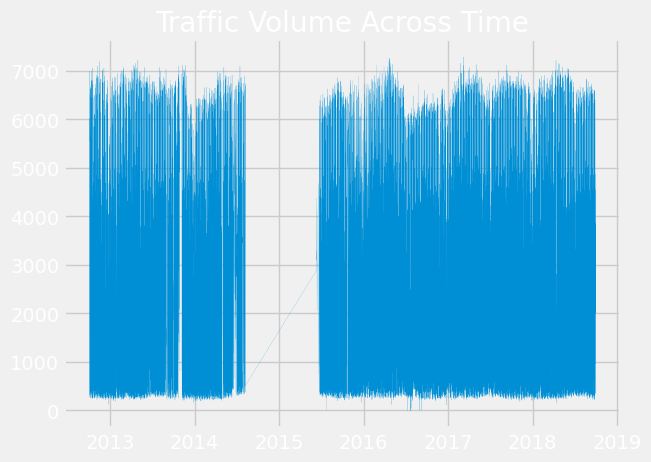

In [11]:
plt.plot(traffic_df.index,
         traffic_df['traffic_volume'],
         linewidth = 0.1)
plt.title("Traffic Volume Across Time")
plt.show()

# Time Series Cross Validation

In [12]:
# We will create a new dataframe called future_data that will be used to evaluate the model
future_data = traffic_df.loc[(traffic_df.index >= '2018-09-25')]

# The model will be trained and tested with the following dataframe
traffic_df = traffic_df.loc[(traffic_df.index < '2018-09-25')]

In [13]:
from sklearn.model_selection import TimeSeriesSplit

# Now we will create train-test splits
tss = TimeSeriesSplit(n_splits = 10, gap = 0)
traffic_df = traffic_df.sort_index()

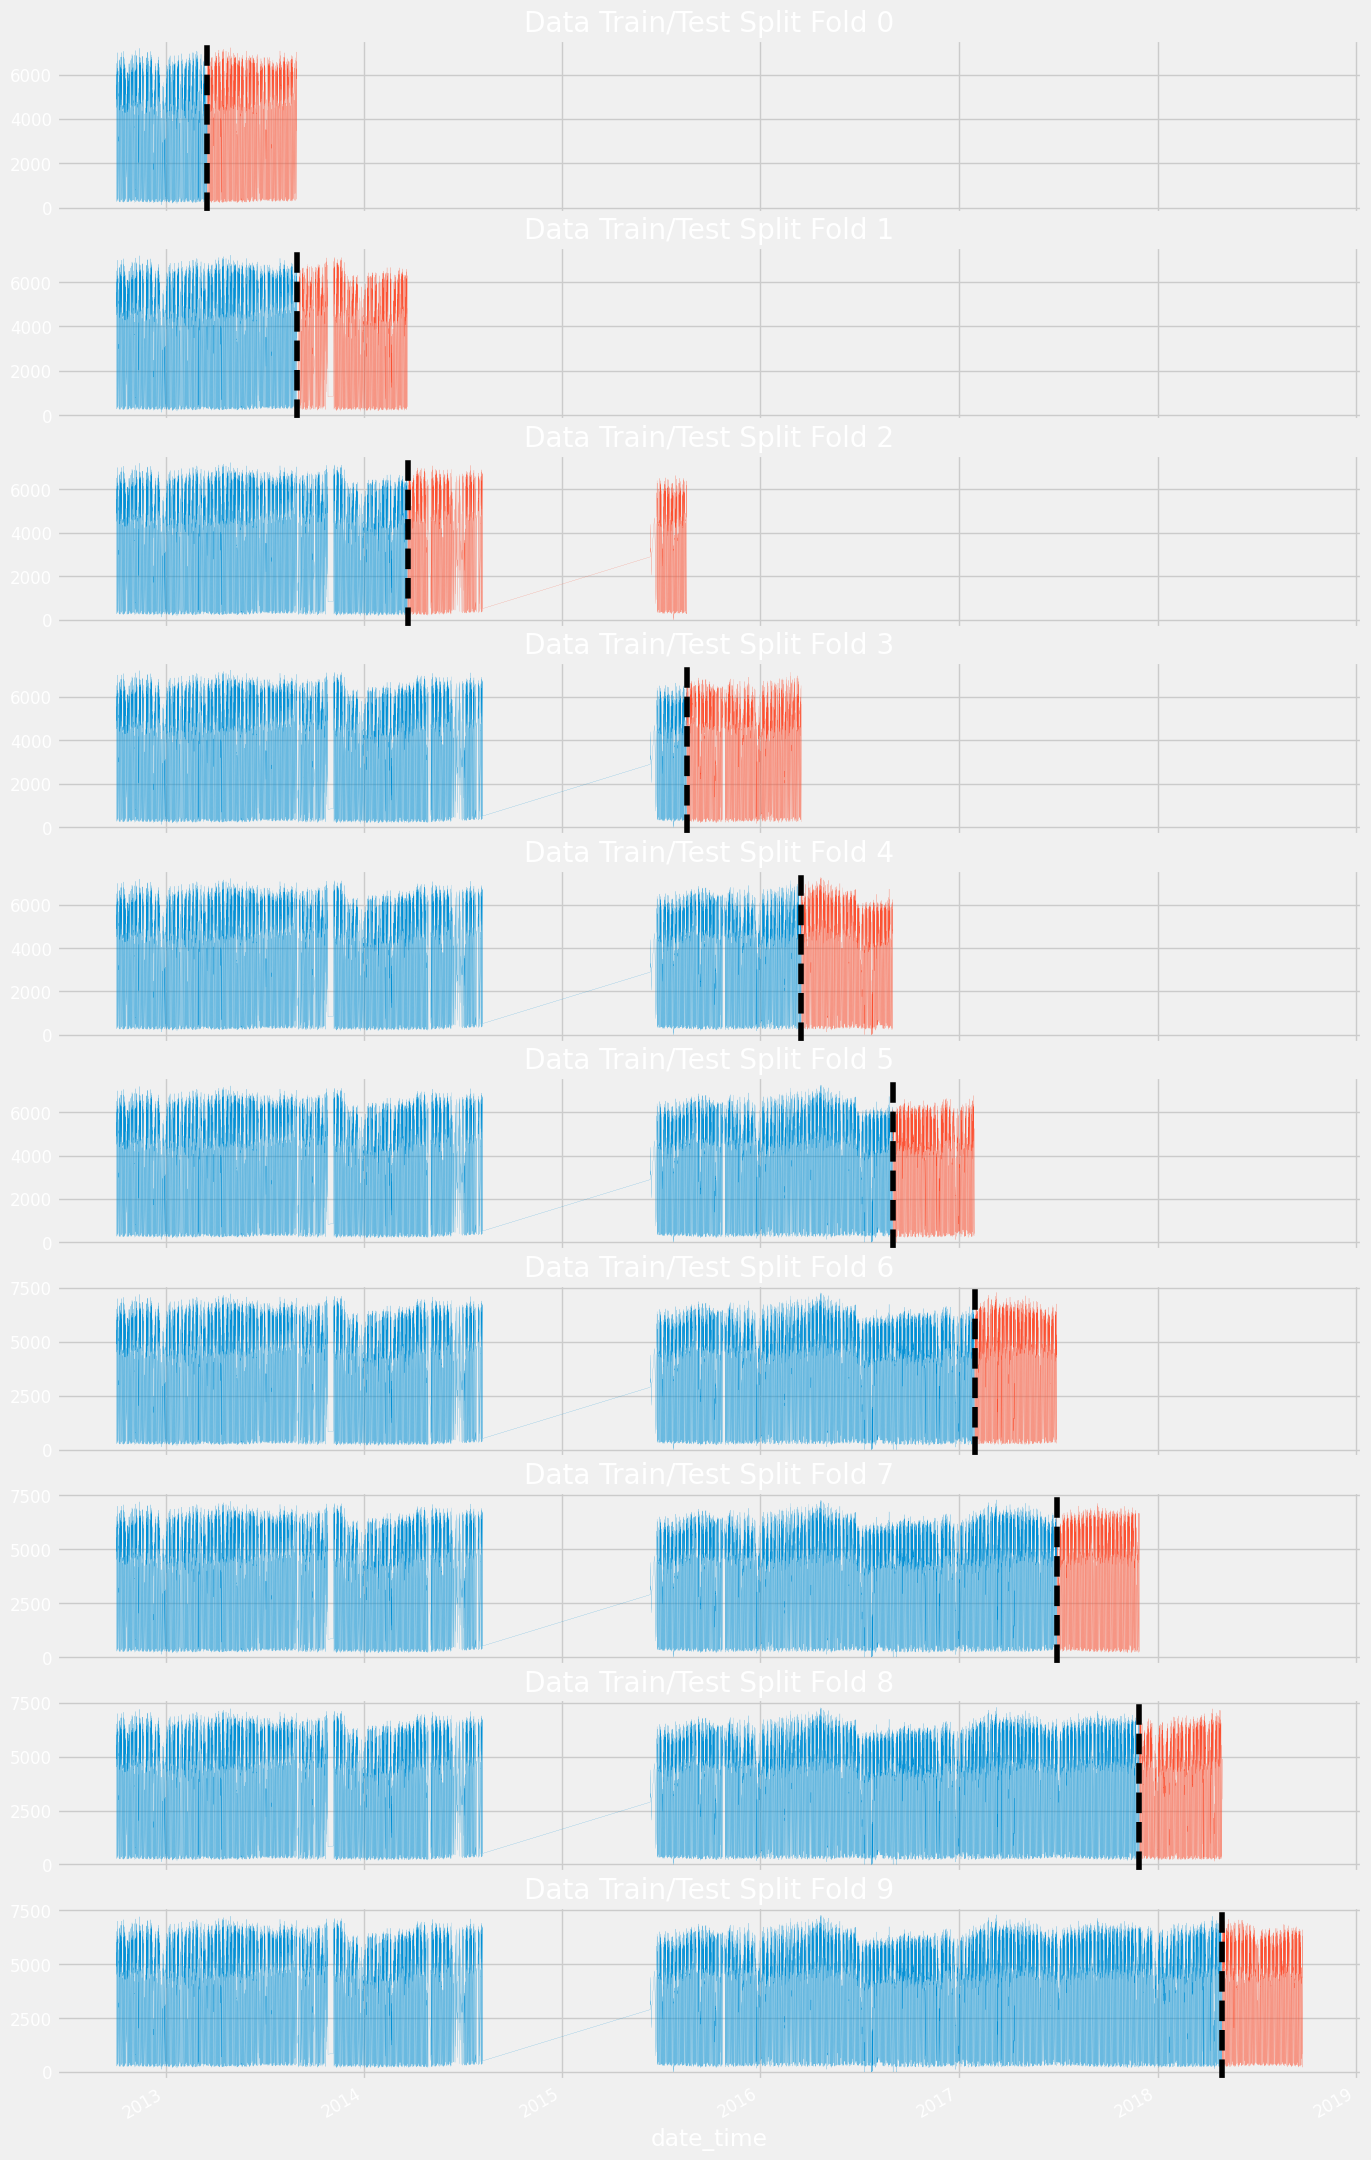

In [14]:
# Here we visualize these train-test splits
fig, axs = plt.subplots(10, 1, figsize = (15, 30), sharex = True)
fold = 0

for train_idx, val_idx in tss.split(traffic_df):
    
    train = traffic_df.iloc[train_idx]
    test = traffic_df.iloc[val_idx]
    
    train['traffic_volume'].plot(ax = axs[fold],
                                 label = 'Training Set',
                                 title = f'Data Train/Test Split Fold {fold}',
                                 fontsize = 12,
                                 linewidth = 0.1)
    
    test['traffic_volume'].plot(ax = axs[fold],
                                label = 'Test Set',
                                linewidth = 0.1)
    
    axs[fold].axvline(test.index.min(), 
                      color = 'black',
                      ls = '--')
    fold += 1
    
plt.show()

# Feature Engineering

In [15]:
def create_features(df):
    
    df = df.copy()
    
    # Time Features
    df['DayOfYear']  = df.index.dayofyear
    df['DayOfMonth'] = df.index.day
    df['DayOfWeek']  = df.index.dayofweek
    df['Year']       = df.index.year
    df['Month']      = df.index.month
    df['Hour']       = df.index.hour
    
    # Holiday Boolean
    df['isHoliday'] = np.where(df['holiday'] != "None", True, False)
    
    return df

In [16]:
traffic_df = create_features(traffic_df)

## Quantifying Categorical Variables

In [17]:
# See the unique values
traffic_df['weather_main'].unique()

array(['Clouds', 'Clear', 'Rain', 'Drizzle', 'Mist', 'Haze', 'Fog',
       'Thunderstorm', 'Snow', 'Squall', 'Smoke'], dtype=object)

In [18]:
traffic_df['holiday'].unique()

array(['nan', 'Columbus Day', 'Veterans Day', 'Thanksgiving Day',
       'Christmas Day', 'New Years Day', 'Washingtons Birthday',
       'Memorial Day', 'Independence Day', 'State Fair', 'Labor Day',
       'Martin Luther King Jr Day'], dtype=object)

In [19]:
# Extract the values from the weather_main column into a variable

unique_weathers = traffic_df['weather_main'].values

# Creatw a new column where we factorize the values of weather_main

traffic_df['weath_cat'] = pd.factorize(unique_weathers)[0]
traffic_df.tail()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,DayOfYear,DayOfMonth,DayOfWeek,Year,Month,Hour,isHoliday,weath_cat
date_time,,,,,,,,,,,,,,,,
2018-09-24 22:00:00,1392,nan,290.01,2.29,0.0,90,Mist,mist,267,24,0,2018,9,22,True,4
2018-09-24 22:00:00,1392,nan,290.01,2.29,0.0,90,Drizzle,light intensity drizzle,267,24,0,2018,9,22,True,3
2018-09-24 23:00:00,826,nan,288.62,4.74,0.0,90,Rain,heavy intensity rain,267,24,0,2018,9,23,True,2
2018-09-24 23:00:00,826,nan,288.62,4.74,0.0,90,Mist,mist,267,24,0,2018,9,23,True,4
2018-09-24 23:00:00,826,nan,288.62,4.74,0.0,90,Thunderstorm,thunderstorm with heavy rain,267,24,0,2018,9,23,True,7


In [20]:
# Repeat the process for the holiday and weather_desc columns

holidays = traffic_df['holiday'].values
traffic_df['holiday_cat'] = pd.factorize(holidays)[0]

weather_descs = traffic_df['weather_description'].values
traffic_df['weather_desc_cat'] = pd.factorize(weather_descs)[0]

# Checkthe newly created weather_desc_cat column to ensure a max of 37

traffic_df['weather_desc_cat'].describe()

count    48049.000000
mean         6.776020
std          8.030284
min          0.000000
25%          2.000000
50%          3.000000
75%          7.000000
max         37.000000
Name: weather_desc_cat, dtype: float64

In [21]:
# Call the info() function to ensure no nulls exist in our new columns
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48049 entries, 2012-10-02 09:00:00 to 2018-09-24 23:00:00
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48049 non-null  int64  
 1   holiday              48049 non-null  object 
 2   temp                 48049 non-null  float64
 3   rain_1h              48049 non-null  float64
 4   snow_1h              48049 non-null  float64
 5   clouds_all           48049 non-null  int64  
 6   weather_main         48049 non-null  object 
 7   weather_description  48049 non-null  object 
 8   DayOfYear            48049 non-null  int32  
 9   DayOfMonth           48049 non-null  int32  
 10  DayOfWeek            48049 non-null  int32  
 11  Year                 48049 non-null  int32  
 12  Month                48049 non-null  int32  
 13  Hour                 48049 non-null  int32  
 14  isHoliday            48049 non-null  bool   
 15  w

In [22]:
traffic_df = traffic_df.drop(['holiday','weather_main','weather_description'], axis =1)
traffic_df.head()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,DayOfYear,DayOfMonth,DayOfWeek,Year,Month,Hour,isHoliday,weath_cat,holiday_cat,weather_desc_cat
date_time,,,,,,,,,,,,,,,
2012-10-02 09:00:00,5545,288.28,0.0,0.0,40,276,2,1,2012,10,9,True,0,0,0
2012-10-02 10:00:00,4516,289.36,0.0,0.0,75,276,2,1,2012,10,10,True,0,0,1
2012-10-02 11:00:00,4767,289.58,0.0,0.0,90,276,2,1,2012,10,11,True,0,0,2
2012-10-02 12:00:00,5026,290.13,0.0,0.0,90,276,2,1,2012,10,12,True,0,0,2
2012-10-02 13:00:00,4918,291.14,0.0,0.0,75,276,2,1,2012,10,13,True,0,0,1


## Feature Cross-Correlation
Visualize the correlation of features to diagnose any concerns of multicollinearity.

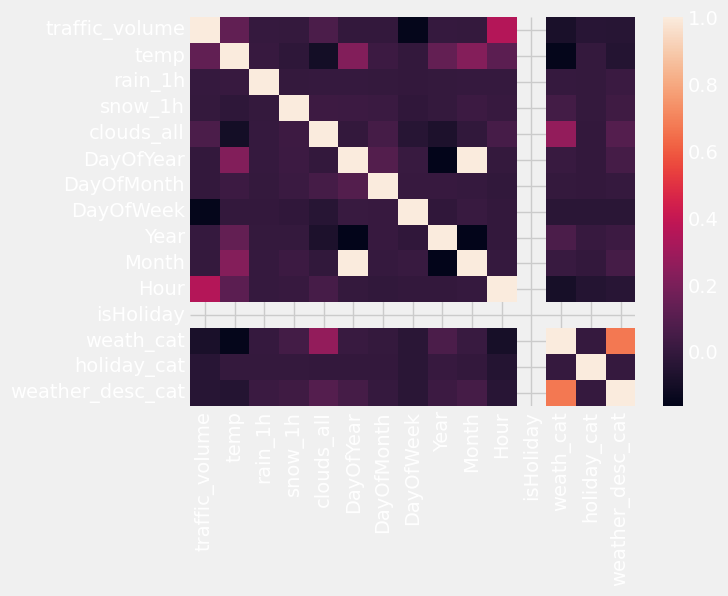

In [23]:
corr_mat = sns.heatmap(traffic_df.corr())
plt.show()

# A Bit of Exploring
We see in the plot above that `Hour` is the major variable correlated with `traffic_volume`. Another variable with weaker correlation is `temp`. Let's see how traffic volume actually changes throughout the day and month. We also check if we can identify any sort of trend throughout the years.

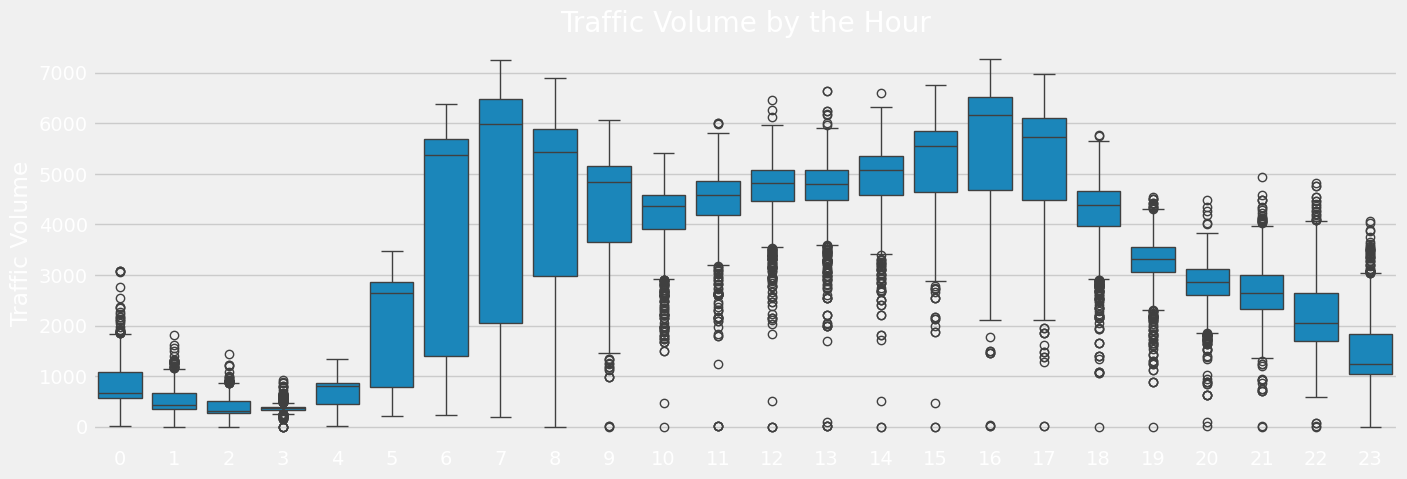

In [24]:
fig, ax = plt.subplots(figsize = (15,5))
sns.boxplot(data = traffic_df, x = 'Hour', y = 'traffic_volume')
ax.set_title('Traffic Volume by the Hour')
plt.xlabel("")
plt.ylabel("Traffic Volume")
plt.show();

/var/folders/12/4hchqrtx79g6hlvzd3njx1140000gn/T/ipykernel_98870/1293528228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = traffic_df, x = 'DayOfMonth', y = 'traffic_volume', palette = 'Reds')


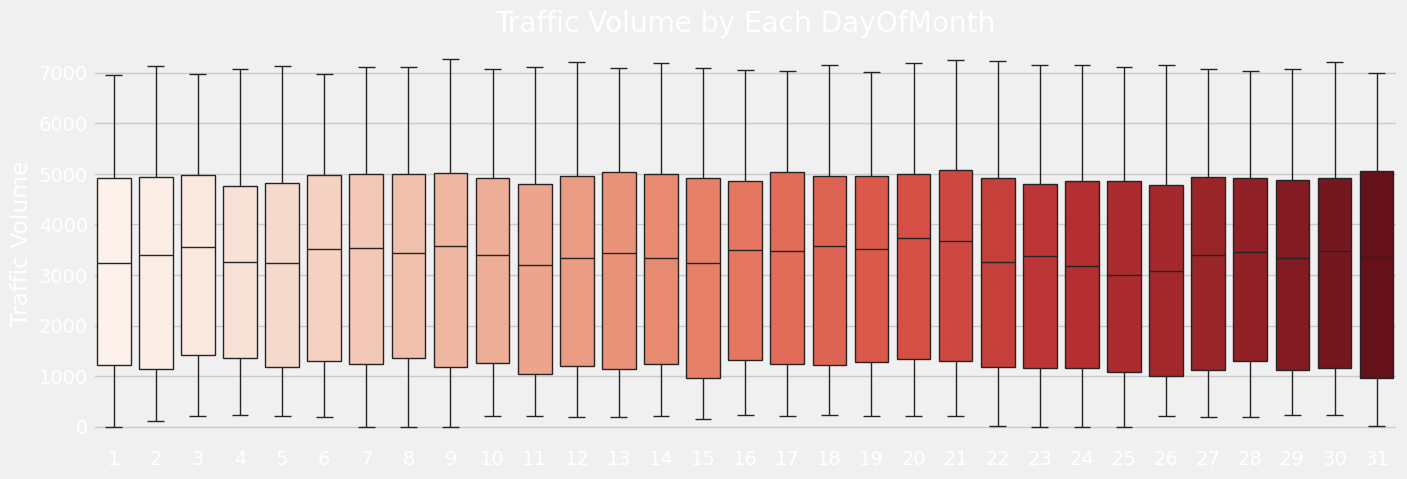

In [25]:
fig, ax = plt.subplots(figsize = (15,5))
sns.boxplot(data = traffic_df, x = 'DayOfMonth', y = 'traffic_volume', palette = 'Reds')
ax.set_title('Traffic Volume by Each DayOfMonth')
plt.xlabel("")
plt.ylabel("Traffic Volume")
plt.show();

/var/folders/12/4hchqrtx79g6hlvzd3njx1140000gn/T/ipykernel_98870/2930649463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = traffic_df, x = 'Year', y = 'traffic_volume', palette = 'Wistia')


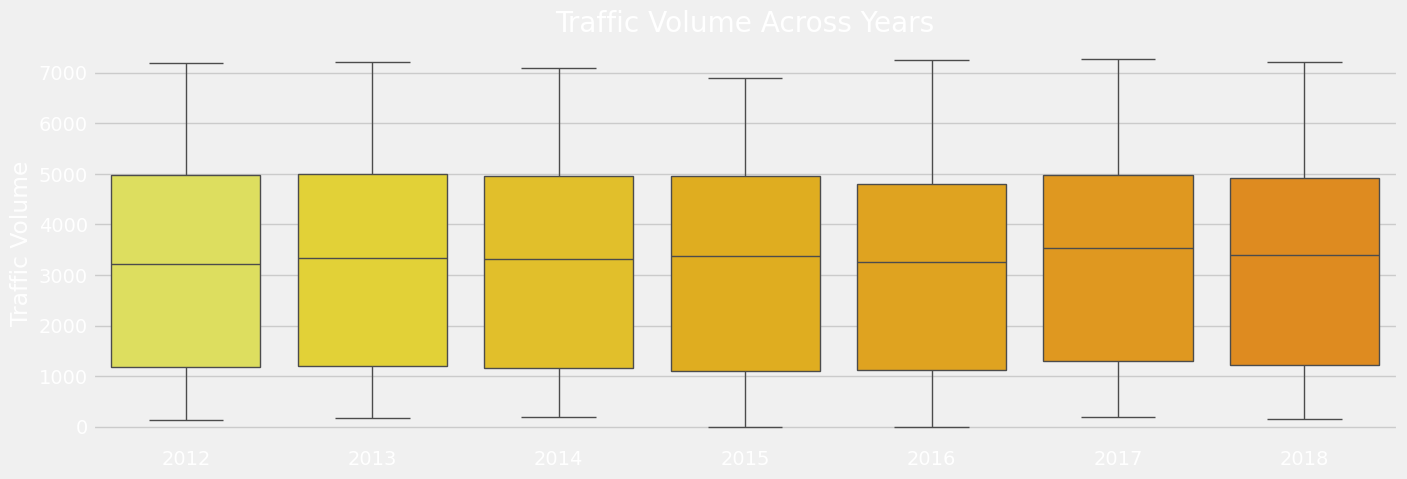

In [26]:
fig, ax = plt.subplots(figsize = (15,5))
sns.boxplot(data = traffic_df, x = 'Year', y = 'traffic_volume', palette = 'Wistia')
ax.set_title('Traffic Volume Across Years')
plt.xlabel("")
plt.ylabel("Traffic Volume")
plt.show();

# Creating Lag Variables

In [27]:
def create_lag(df):
    target_map = df['traffic_volume'].to_dict()

    # Hour Lag
    df['lag1'] = (df.index - pd.Timedelta(1, "h")).map(target_map)

    # Day Lag
    df['lag2'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('28 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('364 days')).map(target_map)

    # Moving Averages
    df['7D_SMA'] = df['traffic_volume'].rolling(168).mean().shift(1) # 7 * 24 = 168
    return df

In [28]:
traffic_df = create_lag(traffic_df)

# Building the Model
Now, we can actually start training our model. We have chosen several lag variables and features. These were motivated by general intuition of how highways operate.

In [29]:
from sklearn.model_selection import GridSearchCV

initial_prediction = traffic_df['traffic_volume'].iloc[-1]

FEATURES = ['DayOfYear', 'DayOfMonth', 'DayOfWeek', 'Year', 'Month',
            'Hour', 'isHoliday', 'lag1', 'lag2', 'lag3', 'lag4', '7D_SMA']

TARGET = 'traffic_volume'

X = traffic_df[FEATURES]
y = traffic_df[TARGET]

params = {'base_score' : [initial_prediction], 
          'booster' : ['gbtree'],    
          'n_estimators' : [2000],
          'objective' : ['reg:squarederror'],
          'learning_rate': [0.01],
          'gamma' : [0.25, 0.5],
          'alpha' : [0],     # L1 (Lasso Regression) Regularization Parameter
          'lambda' : [1.25], # L2 (Ridge Regression) Regularization Parameter
          'max_depth': [3],
          'min_child_weight': [1],
          'random_state' : [42]
         }

model = xgb.XGBRegressor()

grid_search = GridSearchCV(estimator = model, 
                           param_grid = params, 
                           scoring = 'neg_mean_absolute_percentage_error',
                           n_jobs = -1, 
                           cv = tss,  
                           refit = True).fit(X, y)

best_params = grid_search.best_params_
print(f'Model: {model} The best parameters are: {best_params}')

Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) The best parameters are: {'alpha': 0, 'base_score': np.int64(826), 'booster': 'gbtree', 'gamma': 0.25, 'lambda': 1.25, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 2000, 'objective': 'reg:squarederror', 'random_st

In [30]:
# Retrain all the data
final_model = xgb.XGBRegressor(**best_params) # Unpack dictionary
final_model.fit(X, y)

XGBRegressor(alpha=0, base_score=np.int64(826), booster='gbtree',
             callbacks=None, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.25, grow_policy=None, importance_type=None,
             interaction_constraints=None, lambda=1.25, learning_rate=0.01,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2000, n_jobs=None, ...)

## Feature Importance
Here we calculate the importance of each variable to the result of the prediction.

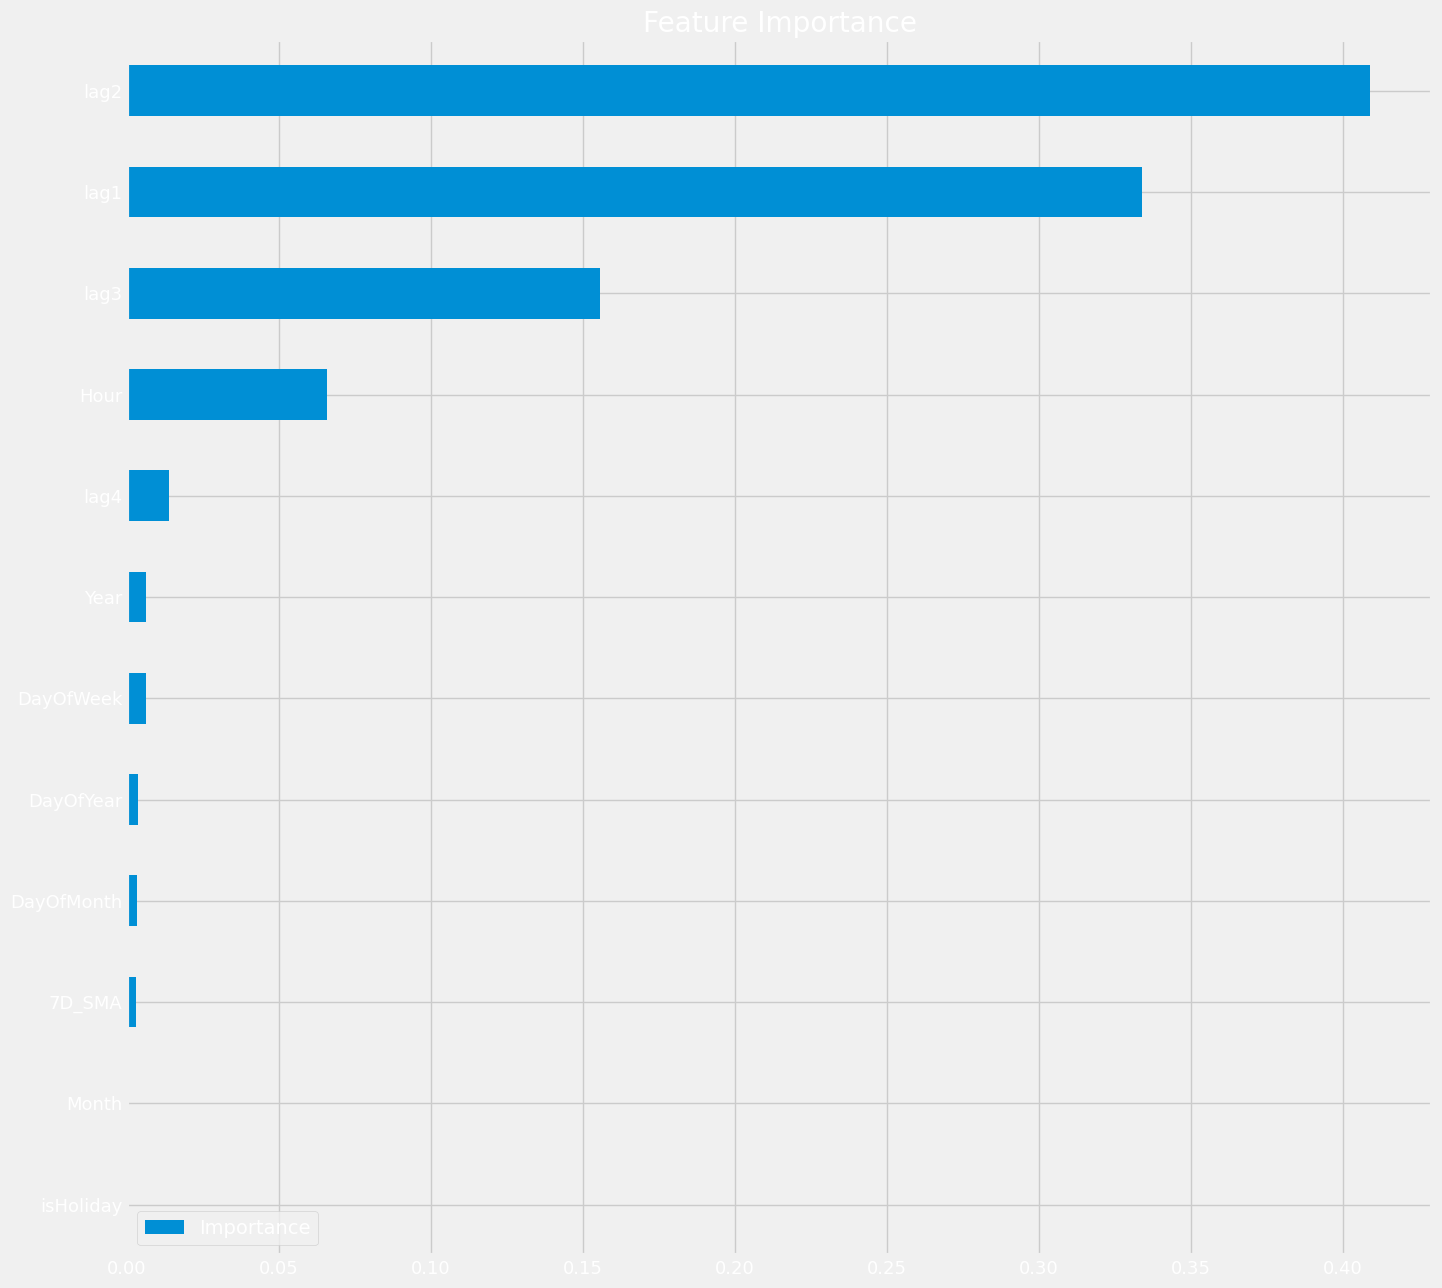

In [31]:
fi = pd.DataFrame(data = final_model.feature_importances_, index = final_model.feature_names_in_,
                  columns = ['Importance'])
fi.sort_values('Importance').plot(kind = 'barh', title = 'Feature Importance', fontsize = 13, figsize = (15,15))
plt.show()

## Evaluating the Forecast

In [33]:
# Download data and create future DataFrame
future_data['isFuture'] = True
traffic_df['isFuture'] = False

# Create dataframe to compare the two datasets later on
comparison_df = pd.DataFrame(future_data['traffic_volume'])

# We should also clear the data columns for the future data
# This makes sure we don't use future unknown data for our prediction
future_data['clouds_all'] = np.nan
future_data['rain_1h'] = np.nan
future_data['snow_1h'] = np.nan
future_data['temp'] = np.nan
future_data['traffic_volume'] = np.nan
future_data['weather_description'] = np.nan
future_data['weather_main'] = np.nan

# We don't need to do this for 'holiday', because we already know the calendar in advance

present_and_future = pd.concat([traffic_df, future_data])
present_and_future = create_features(present_and_future)
present_and_future = create_lag(present_and_future)

In [34]:
# Predicting the future and compare with actual data
future_w_features = present_and_future.query('isFuture').copy()

# Run the model
future_w_features['Prediction'] = final_model.predict(future_w_features[FEATURES])

# Merge the prediction and comparison datasets to evaluate our results
final_df = comparison_df.merge(future_w_features['Prediction'], how = 'left', left_index = True, right_index = True)

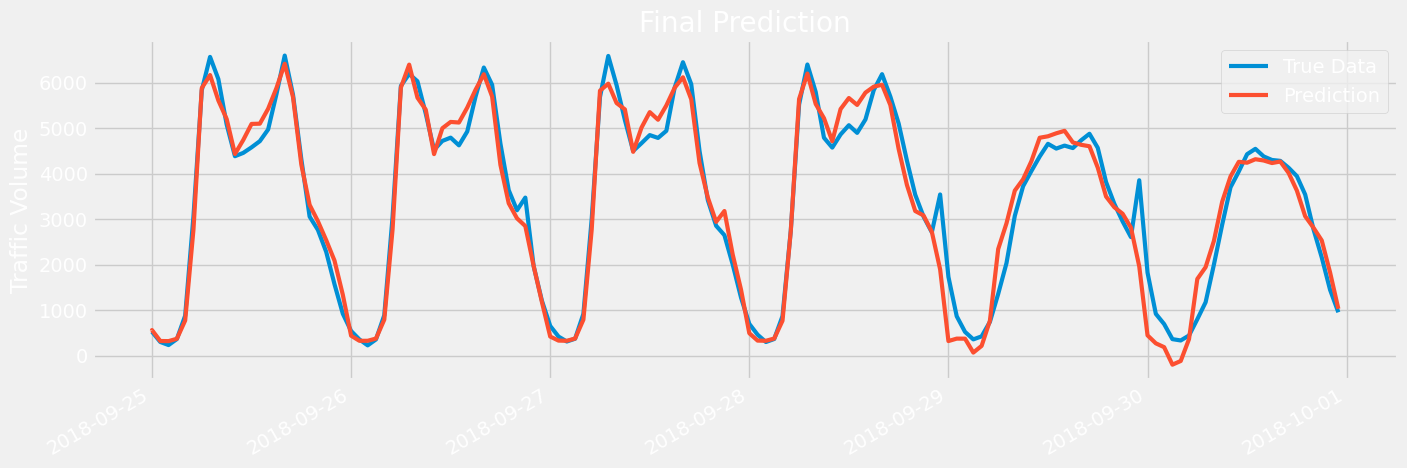

In [35]:
# Plot the data
ax = final_df[['traffic_volume']].plot(figsize = (15,5), linewidth = 3)
final_df['Prediction'].plot(ax = ax, linewidth = 3)
plt.legend(['True Data', 'Prediction'])
plt.xlabel("")
plt.ylabel("Traffic Volume")
ax.set_title('Final Prediction')
plt.show()

In [36]:
mape_score = mean_absolute_percentage_error(final_df['traffic_volume'], final_df['Prediction']) * 100
rmse_score = np.sqrt(mean_squared_error(final_df['traffic_volume'], final_df['Prediction']))
print(f'MAPE on Target Data: {mape_score:0.2f}%')
print(f'RMSE on Target Data: {rmse_score:0.2f}')

MAPE on Target Data: 14.74%
RMSE on Target Data: 412.22
